The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


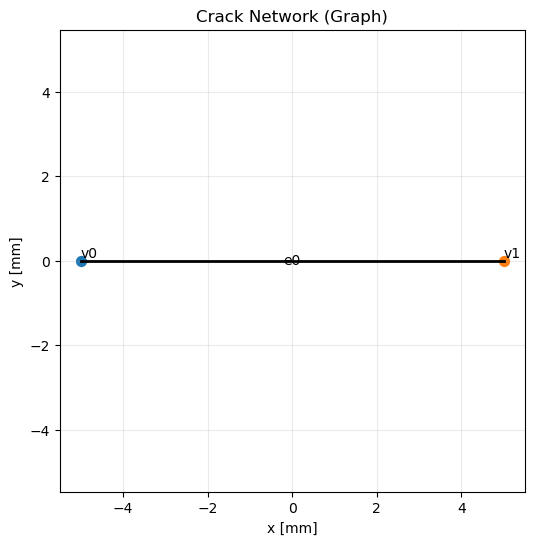

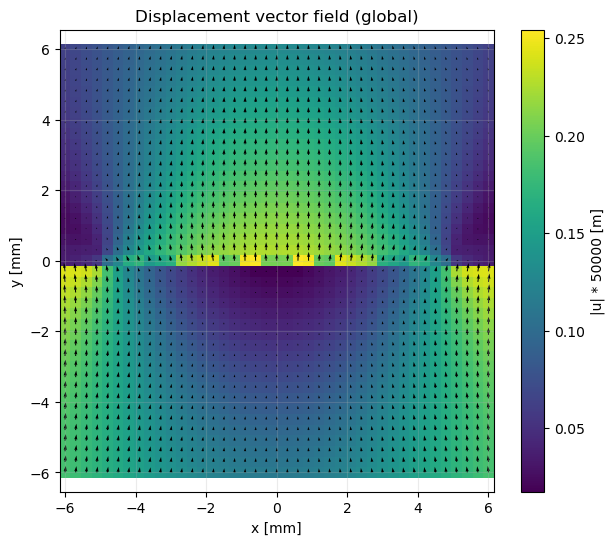

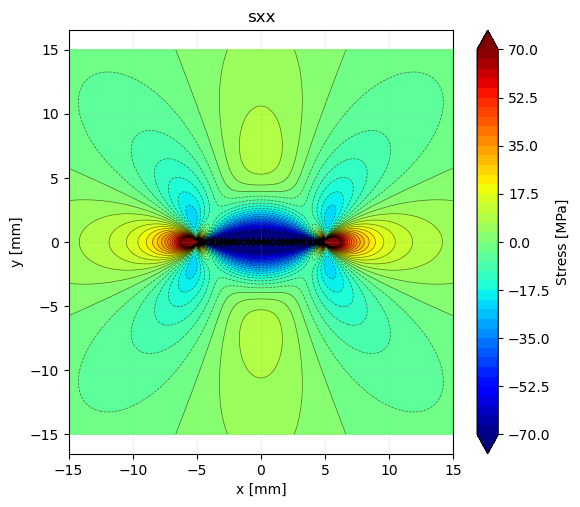

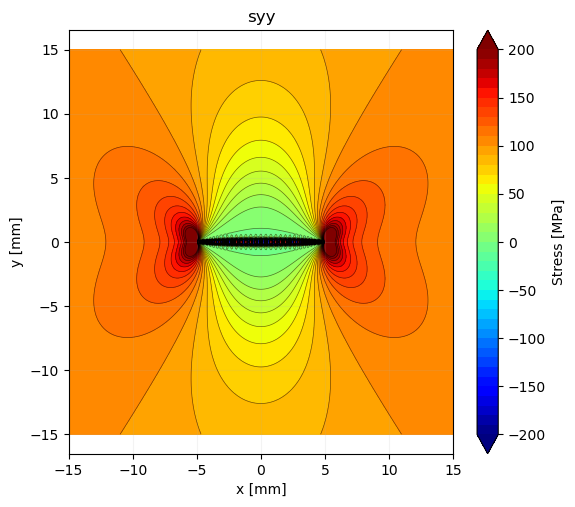

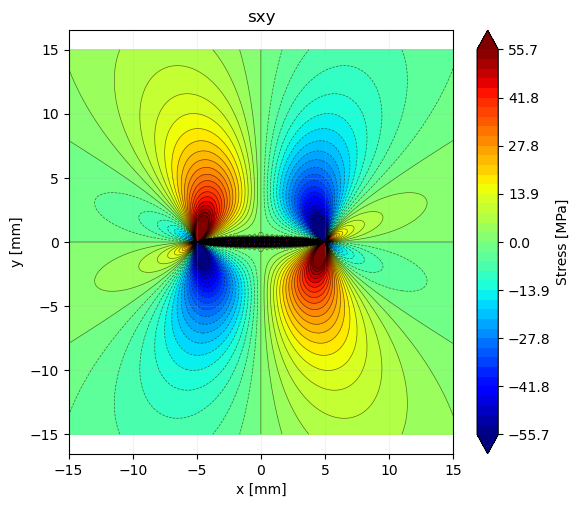

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


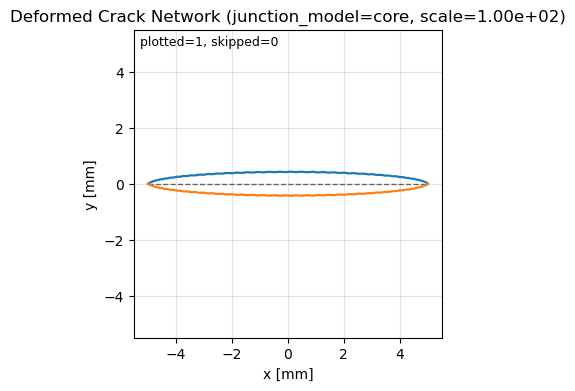

(<Figure size 650x400 with 1 Axes>,
 <Axes: title={'center': 'Deformed Crack Network (junction_model=core, scale=1.00e+02)'}, xlabel='x [mm]', ylabel='y [mm]'>)

In [4]:
import numpy as np
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  0.0*mm],   
    [1,   5.0*mm,  0*mm], 
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    enforce_cod_nonnegative=True,
    cod_tol=1e-10,
    cod_max_iter=25,
)


res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=1e2,
    show_faces=True,
    units="mm",
    cod_smooth_window=5,
    csd_smooth_window=5,
    junction_model="core",
)

Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation


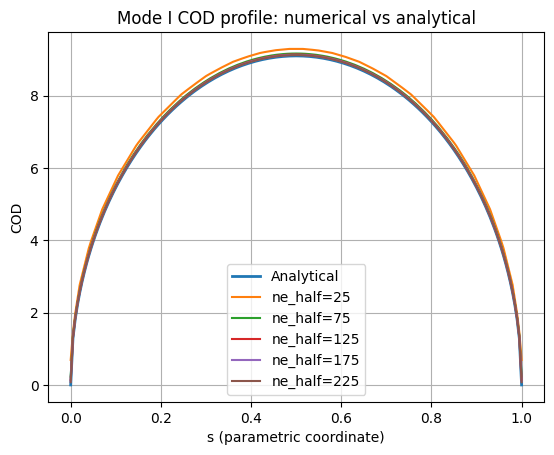

Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation/cod_overlay_ne_half.png
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation/cod_combined_errors_vs_ne_half.png

All plots saved to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation


In [3]:
# --- COD Validation Cell (fixed calc/network wiring) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path(os.getcwd()).resolve()

# Find the nearest parent that contains a "fracture_utils" folder
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break

if repo_root is None:
    # Fallback: hardcode the path you already see in tracebacks
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from fracture_utils.UValidation.validation_cod import (
    CODProfile,
    run_cod_sweep,
    plot_cod_overlay,
    plot_cod_error_vs_knob,
)

from preamble import *
enable_autoreload()

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# Verify directory was created
print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# -------------------------
# Crack/physics metadata (benchmark)
# IMPORTANT: keep 'a' consistent with the geometric half-length used below.
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (meters)

crack_meta = dict(
    a=a_geom,
    sigma=100e6,       # magnitude used in analytical COD (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",    # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Define a single straight crack network (one edge)
# Use a HORIZONTAL crack for Mode I under sigma_yy tension.
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],   # [id, x, y]
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([
    [0, 1],              # edge from v0 -> v1
], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=("stress" in crack_meta["plane"].lower()))

# Remote loading: uniform tension in y gives Mode I for a horizontal crack
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)

# IMPORTANT:
#   - "network" is the geometry
#   - "calc" is the solver object that HAS calc.network, calc.material, calc.applied
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# COD solver hook for validation_cod.run_cod_sweep
# -------------------------
def run_solver_cod(knobs, crack_meta):
    """
    Return CODProfile(s, COD) for one edge using panel-midpoint reconstruction.
    COD is stored in MICRONS for plotting convenience.
    """
    sol = calc.solve(**knobs)

    # DCEResultsNetworkV4 expects (calc, sol), not (network, sol)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x = np.asarray(x, float).reshape(-1)
    COD = np.asarray(COD, float).reshape(-1) * 1e6  # Convert meters to microns
    CSD = np.asarray(CSD, float).reshape(-1)
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=COD,  # Now in microns
        meta=dict(x=x, CSD=CSD, **extra),
    )

# -------------------------
# Analytical COD: infinite plate, straight central crack under uniform tension
# delta(x) = (4*sigma/E')*sqrt(a^2 - x^2)
# Returns COD in MICRONS
# -------------------------
def analytical_cod(s, crack_meta):
    a = float(crack_meta["a"])
    sigma = float(crack_meta["sigma"])
    E = float(crack_meta["E"])
    nu = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    cod_m = (4.0 * sigma / Eprime) * np.sqrt(np.maximum(a * a - x * x, 0.0))
    return cod_m * 1e6  # Convert meters to microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=ne,
        crack_mode="full",
        representation="cheb_quad",   # or "panel", "singular", "cheb_quad"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run COD sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_cod,
    analytical_cod=analytical_cod,
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: COD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode I COD profile: numerical vs analytical",
)
if result1 is not None:
    fig1, ax1 = result1  # Unpack the tuple
    filepath1 = out_dir / "cod_overlay_ne_half.png"
    
    # Update y-axis label to reflect microns
    ax1.set_ylabel(r"COD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")  
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

 # Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=12)
ax2.set_ylabel('Relative Error (%)', fontsize=12)
ax2.set_title('Mode I COD Convergence: Error vs Discretization', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

filepath2 = out_dir / "cod_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII


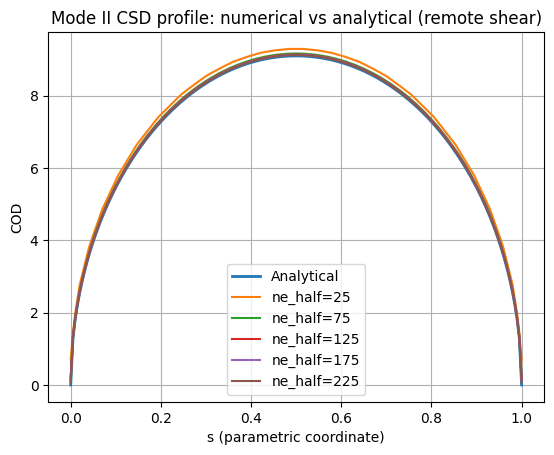

Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII/csd_overlay_ne_half.png
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII/csd_combined_errors_vs_ne_half.png

All plots saved to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII


In [ ]:
#### VALIDATION OF A MODE II CRACK UNDER SHEAR LOADING (CSD)

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cwd = Path(os.getcwd()).resolve()

# Find the nearest parent that contains a "fracture_utils" folder
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break

if repo_root is None:
    # Fallback: hardcode the path you already see in tracebacks
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from fracture_utils.UValidation.validation_cod import (
    CODProfile,        # reuse container (we will store CSD in the 'cod' field)
    run_cod_sweep,
    plot_cod_overlay,
    plot_cod_error_vs_knob,
)

from preamble import *
enable_autoreload()

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture/VCM_1_3/output/CSD_validation_ModeII")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory exists: {out_dir.exists()}")
print(f"Output directory: {out_dir}")

# -------------------------
# Crack/physics metadata (benchmark)
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (m)
tau0   = 100e6      # remote shear (Pa)

crack_meta = dict(
    a=a_geom,
    tau=tau0,         # remote shear magnitude (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",   # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Geometry: single horizontal crack (-a,0) -> (+a,0)
# Mode II: apply uniform remote shear sigma_xy = tau
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(
    E=crack_meta["E"],
    nu=crack_meta["nu"],
    plane_stress=("stress" in crack_meta["plane"].lower()),
)

applied = AppliedStress(
    sigma_xx=0.0,
    sigma_yy=0.0,
    sigma_xy=+crack_meta["tau"],
)

calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Solver hook: return CSD profile using the CODProfile container
# -------------------------
def run_solver_csd(knobs, crack_meta):
    """
    Returns CODProfile(s, csd_um) for one edge.
    We store CSD (sliding displacement jump) in the 'cod' field for reuse of plotting utilities.
    """
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x   = np.asarray(x, float).reshape(-1)
    CSD = np.asarray(CSD, float).reshape(-1) * 1e6  # meters -> microns
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=CSD,  # store CSD in microns
        meta=dict(x=x, **extra),
    )

# -------------------------
# Analytical CSD (Mode II) for infinite plate, central crack under remote shear tau
# delta_t(x) = (4*tau/E') * sqrt(a^2 - x^2)
# Returns CSD in MICRONS.
# -------------------------
def analytical_csd(s, crack_meta):
    a   = float(crack_meta["a"])
    tau = float(crack_meta["tau"])
    E   = float(crack_meta["E"])
    nu  = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    csd_m = (4.0 * tau / Eprime) * np.sqrt(np.maximum(a*a - x*x, 0.0))
    return csd_m * 1e6  # meters -> microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=int(ne),
        crack_mode="full",              # set "half" if validating half-crack formulation
        representation="cheb_quad",     # "panel", "singular", "cheb_quad", "cheb_spectral"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_csd,
    analytical_cod=analytical_csd,   # reuse API; returns CSD
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: CSD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode II CSD profile: numerical vs analytical (remote shear)",
)
if result1 is not None:
    fig1, ax1 = result1
    filepath1 = out_dir / "csd_overlay_ne_half.png"
    ax1.set_ylabel(r"CSD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=12)
ax2.set_ylabel('Relative Error (%)', fontsize=12)
ax2.set_title('Mode II CSD Convergence: Error vs Discretization', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

filepath2 = out_dir / "csd_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/SIF_validation/sif_error_vs_ne_half_ncol12_nsig16_linear.png
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/SIF_validation/sif_error_vs_ne_half_ncol12_nsig16_log.png


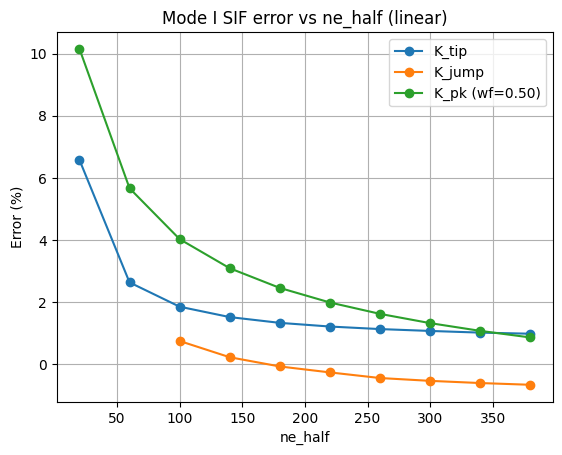

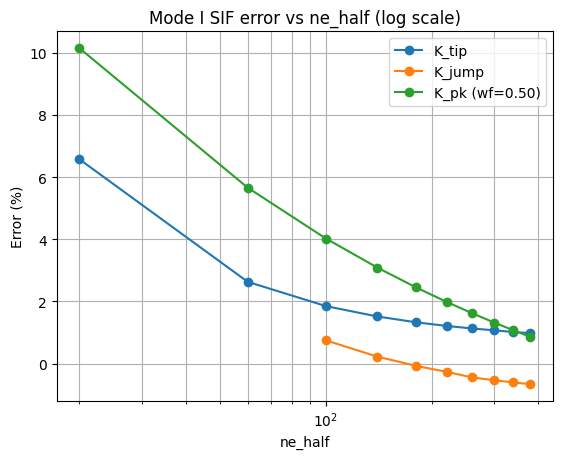

In [ ]:
# --- SIF Validation Cell (4 estimators; PK uses window_frac + normal_offset_frac sweep) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path (robust)
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from preamble import *
enable_autoreload()

# -------------------------
# Imports: updated results + updated PK + SIF utilities
# -------------------------
from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uprocessor.PK import PKProcessor

from fracture_utils.Uprocessor.SIF import (
    sif_from_cod_fit,
    estimate_KI_KII_from_jumps_near_tip,
)

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture/VCM_1_3/output/SIF_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Benchmark: straight crack, Mode I
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm
sigma0 = 100e6

crack_meta = dict(
    a=a_geom,
    sigma=sigma0,
    E=200e9,
    nu=0.30,
    plane="strain",  # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Build a single-edge network
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

plane_stress = ("stress" in str(crack_meta["plane"]).lower())
material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=plane_stress)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Analytical SIF
# -------------------------
def KI_analytic(a, sigma):
    return float(sigma * np.sqrt(np.pi * a))

# -------------------------
# Run one solve and return the 3 "good" estimators + PK (with tunables)
# -------------------------
def solve_and_estimate(ne_half: int, *, window_frac: float, normal_offset_frac: float, representation: str = "cheb_quad"):
    knobs = dict(
        ne_half=int(ne_half),
        crack_mode="half",
        representation=str(representation),
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    )
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=True)
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", float(crack_meta["a"])))

    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa  = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)
    Eprime = E if plane_stress_local else (E / (1.0 - nu**2))

    # Tip-fit
    KI_tip, KII_tip, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit, mu=mu, kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.80,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    # Jump
    KI_jump, KII_jump = estimate_KI_KII_from_jumps_near_tip(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        Eprime=Eprime,
        side="right",
        frac_window=0.08,
    )

    # PK (Mode I: KI = sqrt(E' * J1))
    pk = PKProcessor(res)
    F = pk.F_PK_window(
        edge_index=edge_index,
        at="end",
        exclude_self=True,
        window_panels=0,               # force frac-mode
        window_frac=float(window_frac),
        min_panels=12,
        normal_offset_frac=float(normal_offset_frac),
    )
    if F is None:
        KI_pk = float("nan")
        J1 = float("nan")
    else:
        # local tangent from reconstructor
        _, _, _, extra2 = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=False)
        extra2 = dict(extra2)
        ex = np.asarray(extra2["ex"], float).reshape(2,)
        J1 = float(np.dot(np.asarray(F, float).reshape(2,), ex))
        KI_pk = float(np.sqrt(max(E * J1, 0.0)))

    # Mode I analytic
    KI_ref = KI_analytic(a_fit, float(crack_meta["sigma"]))

    return dict(
        ne_half=int(ne_half),
        a_fit=a_fit,
        Eprime=Eprime,
        KI_ref=KI_ref,
        KI_tip=float(KI_tip),
        KI_jump=float(KI_jump),
        KI_pk=float(KI_pk),
        J1=float(J1),
    )

# -------------------------
# Sweep ne_half with a small grid of PK tunables and plot
# -------------------------
ne_half_list = list(range(20, 420, 40))

# Choose a few combinations (3–5) to avoid crowding
pk_variants = [
    # dict(window_frac=0.20, normal_offset_frac=0.0,    label="wf=0.20, off=0"),
    dict(window_frac=0.50, normal_offset_frac=5e-6, label="wf=0.50"),
]

# Precompute baseline tip/jump once per ne_half (reuse first variant result)
baseline = {}
pk_results = {v["label"]: [] for v in pk_variants}

for ne in ne_half_list:
    r0 = solve_and_estimate(ne, window_frac=pk_variants[0]["window_frac"], normal_offset_frac=pk_variants[0]["normal_offset_frac"])
    baseline[ne] = dict(KI_ref=r0["KI_ref"], KI_tip=r0["KI_tip"], KI_jump=r0["KI_jump"])

    for v in pk_variants:
        r = solve_and_estimate(ne, window_frac=v["window_frac"], normal_offset_frac=v["normal_offset_frac"])
        pk_results[v["label"]].append(r)

# -------------------------
# Plot error vs ne_half
# -------------------------
def err_pct(K, Kref):
    return 100.0 * (K - Kref) / Kref

# First figure: linear x-axis
fig1, ax1 = plt.subplots()
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax1.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax1.set_xlabel("ne_half")
ax1.set_ylabel("Error (%)")
ax1.set_title("Mode I SIF error vs ne_half (linear)")
ax1.grid(True)
ax1.legend()
filepath1 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_linear.png'
fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Second figure: log x-axis
fig2, ax2 = plt.subplots()
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax2.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax2.set_xlabel("ne_half")
ax2.set_ylabel("Error (%)")
ax2.set_title("Mode I SIF error vs ne_half (log scale)")
ax2.set_xscale('log')
ax2.grid(True, which='both')
ax2.legend()
filepath2 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_log.png'
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

plt.show()


Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Solving ne_half = 20

Solving ne_half = 40

Solving ne_half = 60

Solving ne_half = 120


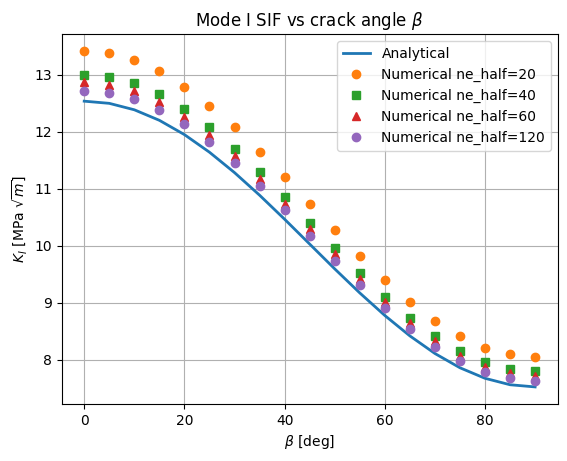

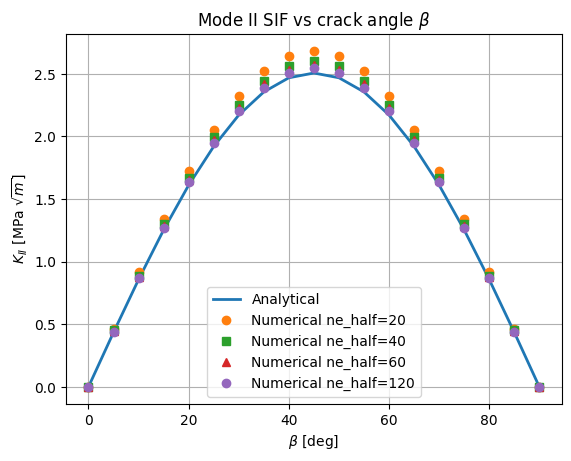


Saved plots to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/MixedMode_SIF_validation


In [ ]:
# --- Mixed-Mode SIF validation: inclined crack under biaxial loading (plots like Fig. B/C) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path (robust)
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)
print("fracture_utils importable =", (repo_root / "fracture_utils").is_dir())

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uprocessor.SIF import sif_from_cod_fit

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture/VCM_1_3/output/MixedMode_SIF_validation")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem definition (match the paper figure)
# Crack length = 2a, inclined by beta from loading axis.
# Analytical (Rooke & Cartwright):
#   KI  = sqrt(pi a) ( σ22 cos^2β + σ11 sin^2β )
#   KII = sqrt(pi a) ( σ22 - σ11 ) sinβ cosβ
# -------------------------
mm = 1e-3
a = 5.0 * mm                  # half-length (m)
sig11 = 60e6                  # Pa  (σ11)
sig22 = 100e6                 # Pa  (σ22)
plane = "strain"              # "strain" or "stress"
edge_index = 0

# Sweep β in degrees (0..90)
beta_deg = np.linspace(0.0, 90.0, 19)
beta_rad = np.deg2rad(beta_deg)

# Numerical resolutions
ne_list = [20, 40, 60, 120]

# Solver knobs (common)
base_knobs = dict(
    crack_mode="full",
    representation="cheb_quad",     # you can switch to "cheb_spectral" once stable
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    parametrization="polyline",
)

# -------------------------
# Helpers
# -------------------------
def analytical_K(beta):
    """Return (KI, KII) for beta (radians)."""
    KI  = np.sqrt(np.pi * a) * (sig22 * (np.cos(beta)**2) + sig11 * (np.sin(beta)**2))
    KII = np.sqrt(np.pi * a) * ((sig22 - sig11) * np.sin(beta) * np.cos(beta))
    return KI, KII

def crack_endpoints(beta):
    """Horizontal crack rotated by beta about origin."""
    c = np.cos(beta); s = np.sin(beta)
    p0 = np.array([-a, 0.0])
    p1 = np.array([+a, 0.0])
    R = np.array([[c, -s],[s, c]])
    q0 = R @ p0
    q1 = R @ p1
    return q0, q1

def solve_K_for_beta(beta, ne_half):
    """Solve for a given beta and ne_half; return (KI_tip, KII_tip)."""
    q0, q1 = crack_endpoints(beta)

    vertices = np.array([
        [0, q0[0], q0[1]],
        [1, q1[0], q1[1]],
    ], dtype=float)

    connectivity = np.array([[0, 1]], dtype=int)

    network = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=3,
        validate=True,
    )

    material = Material(
        E=200e9,
        nu=0.30,
        plane_stress=("stress" in plane.lower()),
    )

    applied = AppliedStress(
        sigma_xx=float(sig11),
        sigma_yy=float(sig22),
        sigma_xy=0.0,
    )

    calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", a))

    # elastic constants for sif_from_cod_fit
    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)

    KI, KII, meta = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.60,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )
    return float(KI), float(KII)

# -------------------------
# Compute curves
# -------------------------
KI_ana = np.zeros_like(beta_deg, float)
KII_ana = np.zeros_like(beta_deg, float)
for i, b in enumerate(beta_rad):
    KI_ana[i], KII_ana[i] = analytical_K(b)

KI_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}
KII_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}

for ne in ne_list:
    print(f"\nSolving ne_half = {ne}")
    for i, b in enumerate(beta_rad):
        KI, KII = solve_K_for_beta(b, ne_half=ne)
        KI_num[ne][i] = KI
        KII_num[ne][i] = KII

# Convert to MPa*sqrt(m) for plotting
scale = 1e-6  # Pa*sqrt(m) -> MPa*sqrt(m)
KI_ana_p = KI_ana * scale
KII_ana_p = KII_ana * scale
KI_num_p = {ne: KI_num[ne] * scale for ne in ne_list}
KII_num_p = {ne: KII_num[ne] * scale for ne in ne_list}

# -------------------------
# Plot (B): KI vs beta
# -------------------------
figB, axB = plt.subplots()
axB.plot(beta_deg, KI_ana_p, label="Analytical", linewidth=2)
markers = {20:"o", 40:"s", 60:"^"}
for ne in ne_list:
    axB.plot(beta_deg, KI_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axB.set_xlabel(r"$\beta$ [deg]")
axB.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
axB.set_title(r"Mode I SIF vs crack angle $\beta$")
axB.grid(True)
axB.legend()
figB.savefig(out_dir / "KI_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# Plot (C): KII vs beta
# -------------------------
figC, axC = plt.subplots()
axC.plot(beta_deg, KII_ana_p, label="Analytical", linewidth=2)
for ne in ne_list:
    axC.plot(beta_deg, KII_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axC.set_xlabel(r"$\beta$ [deg]")
axC.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
axC.set_title(r"Mode II SIF vs crack angle $\beta$")
axC.grid(True)
axC.legend()
figC.savefig(out_dir / "KII_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved plots to: {out_dir}")


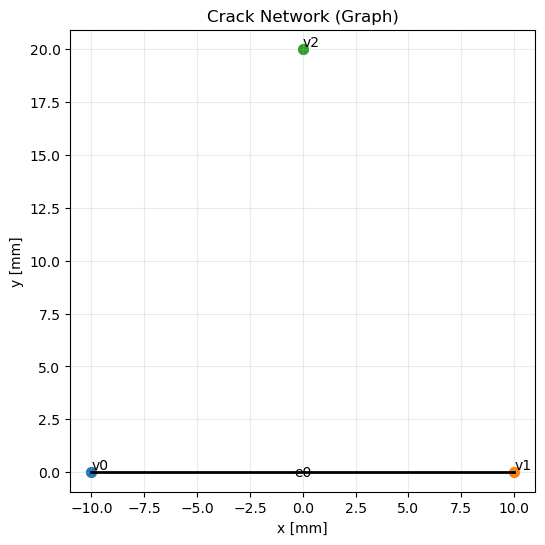

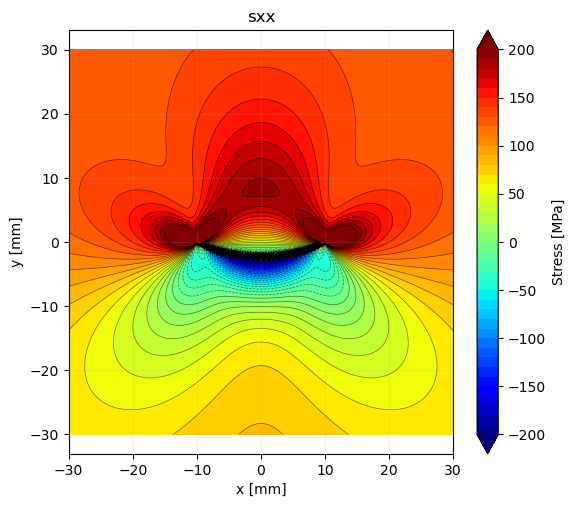

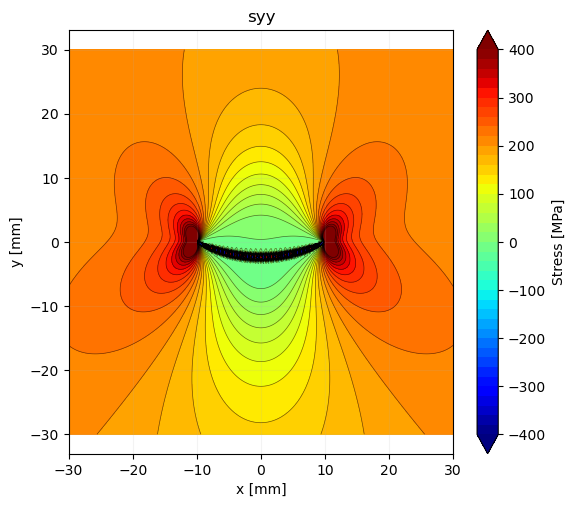

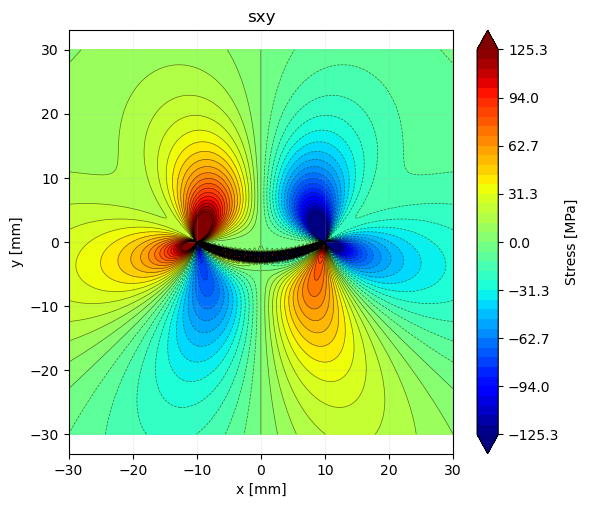

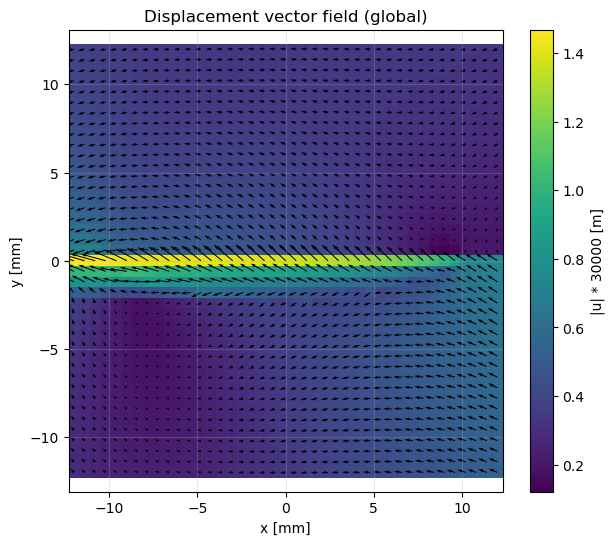

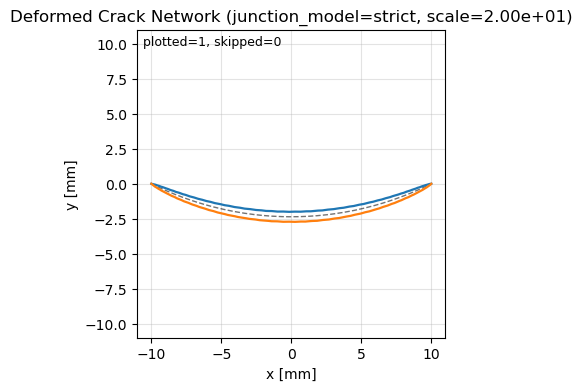

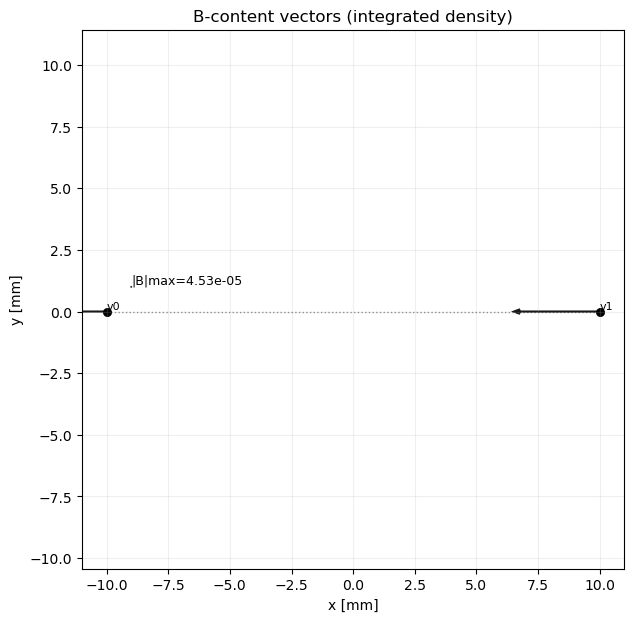

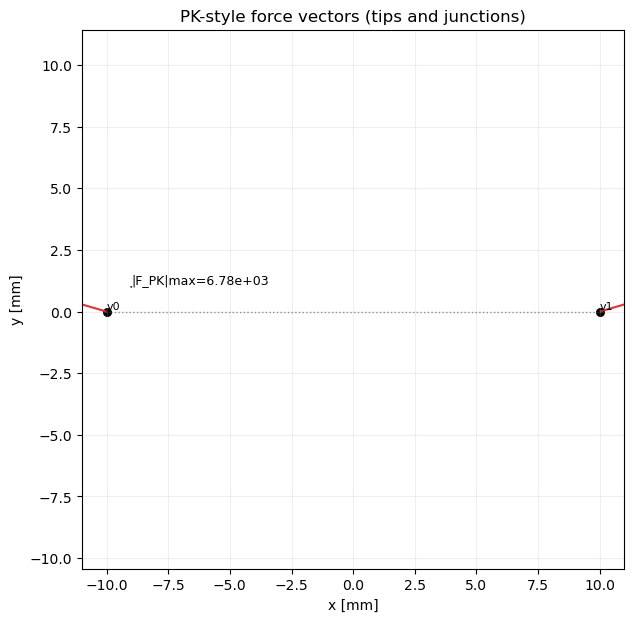

Saved figures to: C\Users\Owner\Documents\Repos\Fracture\Fracture\VCM_1_3\output\CircularKink


In [ ]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import importlib
import preamble
importlib.reload(preamble)

# --- Preamble re-exports
from preamble import *   

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)


# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
a = 10.0 * mm  # crack half-length
alpha_deg = 30.0  # half arc angle in degrees
R = a / np.sin(np.deg2rad(alpha_deg))

V = np.array([
    [0, -a,    0.0],     # endpoint (node)
    [1, a,  0.0],     # endpoint (node)
    [2,  0*mm,  R],    # center (control) 
], float)

E = np.array([
    [0, 1],  
], int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=V,
    connectivity=E,
    Nv_max=4,
    validate=True,
    edge_kinds=["arc"],      # one per edge in E, same order
    edge_ctrl_vids=[(2,)],           # one per edge; only arc gets a center
    vertex_roles={2: "control"},
)


material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100.0e6, sigma_yy=200.0e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(ne_half=40, parametrization="polyline", crack_mode="half",nq_col=12, nq_stress=16, junction_model="strict")


res = DCEResultsNetworkV4(calc, sol)


# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"C:/Users/Owner/Documents/Repos/Fracture/VCM_1_3/output/ArcValidation")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=3e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=2e1,
    show_faces=True,
    units="mm",
    junction_model="strict",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)


Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
[OPT1 arc] ne_half=20
[OPT1 arc] ne_half=40
[OPT1 arc] ne_half=60


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

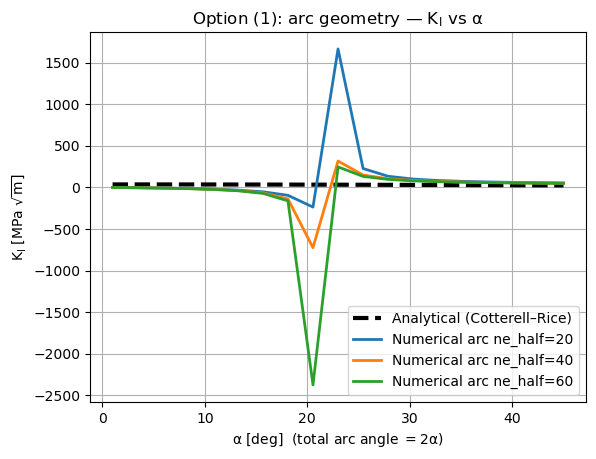

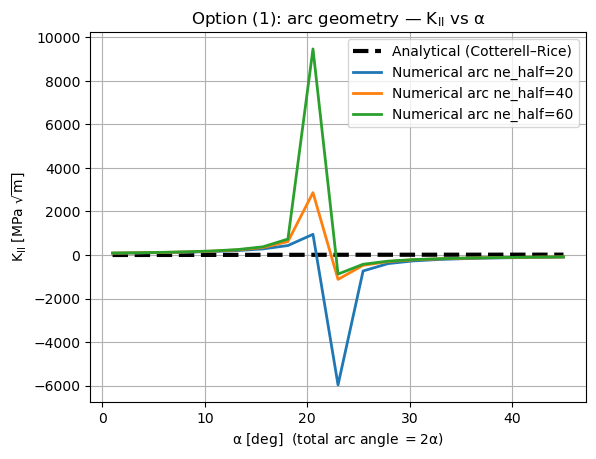

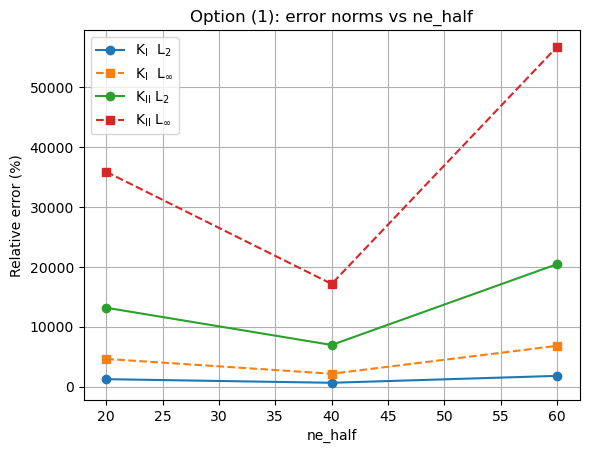

[OPT2 poly] nseg=5, ne_half=60


ValueError: Fit window too small after expansion: rr.size=6. Try increasing rho_max (currently 0.6) or increasing n_pts.

In [ ]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
# total arc angle = 2*alpha  (alpha here is half-angle)
#
# Option (1): arc geometry (edge_kinds=["arc"]), sweep ne_half
# Option (2): polyline geometry, fix ne_half=60, sweep nseg
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path (robust)
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.results import DCEResultsNetworkV4   # <-- use your working import
from fracture_utils.Uprocessor.SIF import sif_from_cod_fit

# -------------------------
# Output directory
# -------------------------
out_dir = Path(repo_root) / "output" / "Arc_CR_CotterellRice"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------

# Inputs
# -------------------------
mm = 1e-3
a = 10.0 * mm                 # half chord length (endpoints at ±a)
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

# Remote stresses (Pa)
sig_xx = 100e6
sig_yy = 200e6
sig_xy = 0.0

# alpha is HALF-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(1.0, 45.0, 19)   # total 2..90 deg
alpha = np.deg2rad(alpha_deg)

# Solver knobs
base_knobs = dict(
    crack_mode="half",                # match your working cell
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",       # IMPORTANT: required by your reconstructor pipeline
)

# -------------------------
# Cotterell–Rice formulas (paper uses total angle = 2*alpha)
# paper has sin(alpha/2), cos(3alpha/2), etc.
# with alpha_paper = 2*alpha => (alpha_paper/2)=alpha, (3alpha_paper/2)=3alpha
# -------------------------
def cotterell_rice_K(alpha, a, sxx, syy, sxy):
    """
    alpha = half-angle (so total included angle is 2*alpha)
    Implements Cotterell–Rice eqs with the paper's alpha = 2*alpha.
    """
    A = alpha  # paper angle

    A0 = 0.5 * (syy + sxx)
    D0 = 0.5 * (syy - sxx)

    s2 = np.sin(A/2.0)  # = sin(alpha)
    c2 = np.cos(A/2.0)  # = cos(alpha)

    bracket = A0 - D0 * (s2**2) * (c2**2)

    KI  = np.sqrt(np.pi * a) * (
        bracket * (c2 / (1.0 + s2**2))
        + D0 * np.cos(3.0*A/2.0)
        - sxy * (np.sin(3.0*A/2.0) + s2**3)
    )

    KII = np.sqrt(np.pi * a) * (
        bracket * (s2 / (1.0 + s2**2))
        + D0 * np.sin(3.0*A/2.0)
        + sxy * (np.cos(3.0*A/2.0) + c2 * (s2**2))
    )
    return KI, KII


# -------------------------
# Geometry helpers
# total angle = 2*alpha
# circle radius: Rcircle = a/sin(alpha)
# sagitta (mid-arc height): h = Rcircle*(1 - cos(alpha))
# control point for your arc encoding is on the arc at (0, h)
# -------------------------
def arc_network(alpha):
    R = a / np.sin(alpha)
    h = R * (1 - np.cos(alpha))

    V = np.array([
        [0, -a, 0.0],   # endpoint
        [1,  a, 0.0],   # endpoint
        [2,  0.0, h],   # control point ON the arc (sagitta)
    ], float)

    Econn = np.array([[0, 1]], int)

    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

    return net

def polyline_network(alpha, nseg):
    # Build true circular arc points using the circle center below chord
    Rcircle = a / np.sin(alpha)
    yc = -Rcircle * np.cos(alpha)  # center below chord gives arc bulging upward
    xc = 0.0

    # endpoints correspond to theta = pi/2 ± alpha (around center)
    thL = np.pi/2.0 + alpha
    thR = np.pi/2.0 - alpha
    th = np.linspace(thL, thR, nseg+1)

    x = xc + Rcircle*np.cos(th)
    y = yc + Rcircle*np.sin(th)

    V = np.zeros((nseg+1, 3), float)
    V[:,0] = np.arange(nseg+1)
    V[:,1] = x
    V[:,2] = y

    Econn = np.array([[i, i+1] for i in range(nseg)], int)

    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=nseg+1,
        validate=True,
    )
    return net

def solve_K(net, ne_half):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane.lower()))
    applied  = AppliedStress(sigma_xx=sig_xx, sigma_yy=sig_yy, sigma_xy=sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", a))

    mu = E/(2.0*(1.0+nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa = (3.0 - nu)/(1.0 + nu) if plane_stress_local else (3.0 - 4.0*nu)

    KI, KII, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit, mu=mu, kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.60,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )
    return float(KI), float(KII)

def rel_L2(num, ana):
    return 100.0*np.linalg.norm(num-ana)/(np.linalg.norm(ana)+1e-30)

def rel_Linf(num, ana):
    return 100.0*np.max(np.abs(num-ana))/(np.max(np.abs(ana))+1e-30)

# -------------------------
# Analytical curves
# -------------------------
KI_ana = np.array([cotterell_rice_K(al, a, sig_xx, sig_yy, sig_xy)[0] for al in alpha])
KII_ana = np.array([cotterell_rice_K(al, a, sig_xx, sig_yy, sig_xy)[1] for al in alpha])

scale = 1e-6
KI_ana_p = KI_ana*scale
KII_ana_p = KII_ana*scale

# ============================================================
# OPTION (1): arc geometry, sweep ne_half
# ============================================================
ne_list = [40]
KI_arc = {ne: np.zeros_like(alpha_deg, float) for ne in ne_list}
KII_arc = {ne: np.zeros_like(alpha_deg, float) for ne in ne_list}

for ne in ne_list:
    print(f"[OPT1 arc] ne_half={ne}")
    for i, al in enumerate(alpha):
        net = arc_network(al)
        KI_arc[ne][i], KII_arc[ne][i] = solve_K(net, ne)

fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for ne in ne_list:
    ax1.plot(alpha_deg, KI_arc[ne]*scale, lw=2, label=f"Numerical arc ne_half={ne}")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Option (1): arc geometry — $K_I$ vs $\\alpha$")
ax1.grid(True); ax1.legend()
fig1.savefig(out_dir/"OPT1_arc_KI_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for ne in ne_list:
    ax2.plot(alpha_deg, KII_arc[ne]*scale, lw=2, label=f"Numerical arc ne_half={ne}")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Option (1): arc geometry — $K_{II}$ vs $\\alpha$")
ax2.grid(True); ax2.legend()
fig2.savefig(out_dir/"OPT1_arc_KII_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

KI_L2 = [rel_L2(KI_arc[ne]*scale, KI_ana_p) for ne in ne_list]
KI_Li = [rel_Linf(KI_arc[ne]*scale, KI_ana_p) for ne in ne_list]
KII_L2 = [rel_L2(KII_arc[ne]*scale, KII_ana_p) for ne in ne_list]
KII_Li = [rel_Linf(KII_arc[ne]*scale, KII_ana_p) for ne in ne_list]

figE1, axE1 = plt.subplots()
axE1.plot(ne_list, KI_L2, "o-", label=r"$K_I$  $L_2$")
axE1.plot(ne_list, KI_Li, "s--", label=r"$K_I$  $L_\infty$")
axE1.plot(ne_list, KII_L2, "o-", label=r"$K_{II}$ $L_2$")
axE1.plot(ne_list, KII_Li, "s--", label=r"$K_{II}$ $L_\infty$")
axE1.set_xlabel("ne_half"); axE1.set_ylabel("Relative error (%)")
axE1.set_title("Option (1): error norms vs ne_half")
axE1.grid(True); axE1.legend()
figE1.savefig(out_dir/"OPT1_arc_error_vs_ne_half.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# OPTION (2): polyline geometry, fix ne_half=60, sweep nseg
# ============================================================
ne_fixed = 60
nseg_list = [20]

KI_poly = {nseg: np.zeros_like(alpha_deg, float) for nseg in nseg_list}
KII_poly = {nseg: np.zeros_like(alpha_deg, float) for nseg in nseg_list}

for nseg in nseg_list:
    print(f"[OPT2 poly] nseg={nseg}, ne_half={ne_fixed}")
    for i, al in enumerate(alpha):
        net = polyline_network(al, nseg=nseg)
        KI_poly[nseg][i], KII_poly[nseg][i] = solve_K(net, ne_fixed)

fig3, ax3 = plt.subplots()
ax3.plot(alpha_deg, KI_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for nseg in nseg_list:
    ax3.plot(alpha_deg, KI_poly[nseg]*scale, lw=2, label=f"Numerical poly nseg={nseg}")
ax3.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax3.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax3.set_title("Option (2): polyline geometry (ne_half=60) — $K_I$ vs $\\alpha$")
ax3.grid(True); ax3.legend()
fig3.savefig(out_dir/"OPT2_poly_KI_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

fig4, ax4 = plt.subplots()
ax4.plot(alpha_deg, KII_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for nseg in nseg_list:
    ax4.plot(alpha_deg, KII_poly[nseg]*scale, lw=2, label=f"Numerical poly nseg={nseg}")
ax4.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax4.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax4.set_title("Option (2): polyline geometry (ne_half=60) — $K_{II}$ vs $\\alpha$")
ax4.grid(True); ax4.legend()
fig4.savefig(out_dir/"OPT2_poly_KII_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

KI_L2s  = [rel_L2(KI_poly[nseg]*scale, KI_ana_p) for nseg in nseg_list]
KI_Lis  = [rel_Linf(KI_poly[nseg]*scale, KI_ana_p) for nseg in nseg_list]
KII_L2s = [rel_L2(KII_poly[nseg]*scale, KII_ana_p) for nseg in nseg_list]
KII_Lis = [rel_Linf(KII_poly[nseg]*scale, KII_ana_p) for nseg in nseg_list]

figE2, axE2 = plt.subplots()
axE2.plot(nseg_list, KI_L2s, "o-", label=r"$K_I$  $L_2$")
axE2.plot(nseg_list, KI_Lis, "s--", label=r"$K_I$  $L_\infty$")
axE2.plot(nseg_list, KII_L2s, "o-", label=r"$K_{II}$ $L_2$")
axE2.plot(nseg_list, KII_Lis, "s--", label=r"$K_{II}$ $L_\infty$")
axE2.set_xlabel("polyline segments (nseg)")
axE2.set_ylabel("Relative error (%)")
axE2.set_title("Option (2): error norms vs nseg (ne_half=60)")
axE2.grid(True); axE2.legend()
figE2.savefig(out_dir/"OPT2_poly_error_vs_nseg.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved all plots to: {out_dir}")


In [4]:
def debug_at_alpha(alpha_deg_test=40.0, ne_half=60, use_arc=True, nseg=50):
    al = np.deg2rad(alpha_deg_test)

    # --- Geometry numbers from your formulas
    R = a / np.sin(al)
    h = R * (1.0 - np.cos(al))
    yc = R * np.cos(al)

    print("\n================ DEBUG at alpha = %.3f deg ================" % alpha_deg_test)
    print("a (input half-chord) =", a)
    print("Rcircle = a/sin(alpha) =", R)
    print("sagitta h = R(1-cos alpha) =", h)
    print("circle center y_c = R cos alpha =", yc)

    # --- Build network (arc vs polyline)
    if use_arc:
        # TRY BOTH interpretations quickly:
        # (A) control is sagitta point
        V_sag = np.array([[0, -a, 0.0],
                          [1,  a, 0.0],
                          [2,  0.0, h]], float)
        # (B) control is circle center
        V_ctr = np.array([[0, -a, 0.0],
                          [1,  a, 0.0],
                          [2,  0.0, yc]], float)

        Econn = np.array([[0,1]], int)

        print("\n--- Using ARC geometry ---")
        print("Try control = sagitta point (0,h)")
        net1 = CrackNetworkV4.from_vertices_connectivity(
            vertices=V_sag, connectivity=Econn, Nv_max=4, validate=True,
            edge_kinds=["arc"], edge_ctrl_vids=[(2,)], vertex_roles={2:"control"},
        )

        print("Try control = circle center (0,yc)")
        net2 = CrackNetworkV4.from_vertices_connectivity(
            vertices=V_ctr, connectivity=Econn, Nv_max=4, validate=True,
            edge_kinds=["arc"], edge_ctrl_vids=[(2,)], vertex_roles={2:"control"},
        )

        nets = [("arc_sagitta", net1), ("arc_center", net2)]
    else:
        print("\n--- Using POLYLINE geometry ---")
        netp = polyline_network(al, nseg=nseg)
        nets = [(f"polyline_nseg={nseg}", netp)]

    # --- Analytic (Cotterell–Rice)
    KI_a, KII_a = cotterell_rice_K(al/2, a, sig_xx, sig_yy, sig_xy)
    print("\nAnalytical (Pa*sqrt(m)):")
    print("  KI  =", KI_a, "   (MPa*sqrt(m))", KI_a*1e-6)
    print("  KII =", KII_a, "   (MPa*sqrt(m))", KII_a*1e-6)

    # --- Solve each network and print reconstruction diagnostics
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane.lower()))
    applied  = AppliedStress(sigma_xx=sig_xx, sigma_yy=sig_yy, sigma_xy=sig_xy)

    for tag, net in nets:
        print("\n--- SOLVE:", tag, "ne_half=", ne_half, "---")

        calc = DCENetworkStaticV4(material, net, applied)
        knobs = dict(base_knobs)
        knobs["ne_half"] = int(ne_half)

        sol = calc.solve(**knobs)
        res = DCEResultsNetworkV4(calc, sol)

        x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
            edge_index=0,
            enforce_global_tip_zero=True,
        )
        extra = dict(extra) if isinstance(extra, dict) else {}

        print("extra keys:", sorted(list(extra.keys()))[:20], "...")
        for k in ["a_edge","Le","ex","ey","segL","path_edges","path_vids"]:
            if k in extra:
                print(f"  extra[{k!r}] =", extra[k])

        a_fit = float(extra.get("a_edge", a))
        print("a_fit used by tip-fit =", a_fit, "(compare to input a =", a, ")")

        mu = E/(2.0*(1.0+nu))
        plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
        kappa = (3.0 - nu)/(1.0 + nu) if plane_stress_local else (3.0 - 4.0*nu)

        KI, KII, meta = sif_from_cod_fit(
            x=x, COD=COD, CSD=CSD,
            a=a_fit, mu=mu, kappa=kappa,
            tip="right",
            window="fixed",
            rho_min=1e-6,
            rho_max=0.60,
            min_pts=10,
            n_fit=400,
            two_term=True,
        )

        print("Numerical (Pa*sqrt(m)):")
        print("  KI  =", KI,  " (MPa*sqrt(m))", KI*1e-6)
        print("  KII =", KII, " (MPa*sqrt(m))", KII*1e-6)

        print("Ratio KI_num/KI_ana =", (KI/KI_a) if KI_a != 0 else np.nan)
        print("============================================================")


debug_at_alpha(alpha_deg_test=30.0, ne_half=60, use_arc=True)



================ DEBUG at alpha = 30.000 deg ================
a (input half-chord) = 0.01
Rcircle = a/sin(alpha) = 0.020000000000000004
sagitta h = R(1-cos alpha) = 0.0026794919243112265
circle center y_c = R cos alpha = 0.017320508075688777

--- Using ARC geometry ---
Try control = sagitta point (0,h)
Try control = circle center (0,yc)

Analytical (Pa*sqrt(m)):
  KI  = 33960779.240350164    (MPa*sqrt(m)) 33.96077924035016
  KII = 6784537.927450923    (MPa*sqrt(m)) 6.7845379274509225

--- SOLVE: arc_sagitta ne_half= 60 ---
extra keys: ['J_mid', 'J_v0', 'J_v1', 'a_edge', 'bI', 'bII', 'dir_sign', 'ex', 'ey', 'p0', 'p1', 'pid', 's_mid', 'xy_mid'] ...
  extra['a_edge'] = 0.01355173351172008
  extra['ex'] = [1. 0.]
  extra['ey'] = [-0.  1.]
a_fit used by tip-fit = 0.01355173351172008 (compare to input a = 0.01 )
Numerical (Pa*sqrt(m)):
  KI  = 80176837.46158658  (MPa*sqrt(m)) 80.17683746158657
  KII = -219110705.3043347  (MPa*sqrt(m)) -219.1107053043347
Ratio KI_num/KI_ana = 2.360865659004

Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[ARC] ne_half = 40


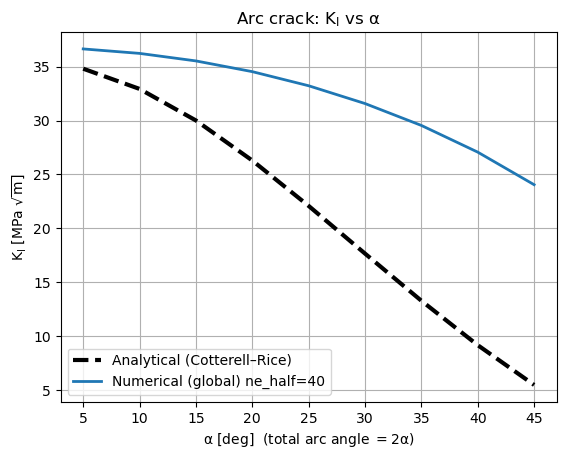

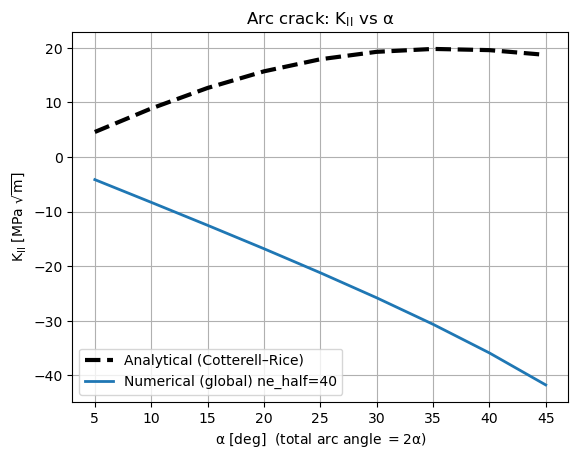

[POLY] nseg=20, ne_half=60


ValueError: Fit window too small after expansion: rr.size=3. Try increasing rho_max (currently 0.6) or increasing n_pts.

In [8]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
# Geometry: total arc angle = 2*alpha  (alpha = half-angle)
#
# Option (1): ARC geometry, sweep ne_half (small subset)
# Option (2): POLYLINE geometry, fix ne_half, sweep nseg (small subset)
#
# Diagnostics printed at alpha = 30 deg at the end
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uprocessor.SIF import sif_from_cod_fit

# -------------------------
# Output directory
# -------------------------
out_dir = Path(repo_root) / "output" / "Arc_CR_CotterellRice"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm       # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 100e6
sig_yy = 200e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(5.0, 45.0, 9)   # small subset
alpha = np.deg2rad(alpha_deg)

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",   # keep what works in your pipeline
)

# -------------------------
# Cotterell–Rice analytical SIFs
# IMPORTANT: CR uses alpha/2 for the TOTAL angle 2*alpha (your geometry),
# so using sin(alpha), cos(alpha), cos(3alpha), sin(3alpha) is correct here.
# Also: use a_arc (half arc-length) in sqrt(pi*a_arc).
# -------------------------
def cotterell_rice_K(alpha, a_arc, sxx, syy, sxy):
    A0 = 0.5 * (syy + sxx)
    D0 = 0.5 * (syy - sxx)

    s = np.sin(alpha)
    c = np.cos(alpha)

    bracket = A0 - D0 * (s**2) * (c**2)

    KI  = np.sqrt(np.pi * a_arc) * (
        bracket * (c / (1.0 + s**2))
        + D0 * np.cos(3.0 * alpha)
        - sxy * (np.sin(3.0 * alpha) + s**3)
    )

    KII = np.sqrt(np.pi * a_arc) * (
        bracket * (s / (1.0 + s**2))
        + D0 * np.sin(3.0 * alpha)
        + sxy * (np.cos(3.0 * alpha) + c * (s**2))
    )

    return float(KI), float(KII)

# -------------------------
# Geometry builders
# ARC control point is the CIRCLE CENTER (your encoding).
# total angle = 2*alpha, chord endpoints = ±a_chord
# R = a/sin(alpha), center y_c = R cos(alpha)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)   # TRUE circle center

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],   # CONTROL = CENTER
    ], float)

    Econn = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

def polyline_network(alpha, nseg):
    R = a_chord / np.sin(alpha)
    yc = R * np.cos(alpha)

    thL = np.pi/2 + alpha
    thR = np.pi/2 - alpha
    th = np.linspace(thL, thR, nseg + 1)

    x = R * np.cos(th)
    y = -yc + R * np.sin(th)

    V = np.zeros((nseg + 1, 3))
    V[:,0] = np.arange(nseg + 1)
    V[:,1] = x
    V[:,2] = y

    Econn = np.array([[i, i+1] for i in range(nseg)], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=nseg + 1,
        validate=True,
    )

# -------------------------
# Correct SIF rotation between local crack-tip frame and global frame
# Complex SIF transforms with half-angle rotation:
# K' = (KI + i KII) * exp(-i theta/2)
# -------------------------
def K_local_to_global(KI, KII, theta):
    c = np.cos(0.5 * theta)
    s = np.sin(0.5 * theta)
    KI_g  = KI * c + KII * s
    KII_g = -KI * s + KII * c
    return float(KI_g), float(KII_g)

# -------------------------
# Solver wrapper (UPDATED signature includes alpha_tip)
# -------------------------
def solve_K(net, ne_half, alpha_tip):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    a_arc = float(extra["a_edge"])  # HALF arc length (matches solver geometry)

    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu)  # plane strain

    KI_loc, KII_loc, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.6,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    KI_g, KII_g = K_local_to_global(KI_loc, KII_loc, theta=alpha_tip)
    return float(KI_loc), float(KII_loc), a_arc, KI_g, float(KII_g)

def rel_L2(num, ana):
    return 100.0*np.linalg.norm(num-ana)/(np.linalg.norm(ana)+1e-30)

def rel_Linf(num, ana):
    return 100.0*np.max(np.abs(num-ana))/(np.max(np.abs(ana))+1e-30)

# ============================================================
# Precompute analytical curves using a_arc = R*alpha
# ============================================================
KI_ana = []
KII_ana = []
a_arc_list = []
for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al
    a_arc_list.append(a_arc)
    KIa, KIIa = cotterell_rice_K(al, a_arc, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

KI_ana = np.array(KI_ana, float)
KII_ana = np.array(KII_ana, float)

scale = 1e-6
KI_ana_p = KI_ana * scale
KII_ana_p = KII_ana * scale

# ============================================================
# OPTION (1): ARC geometry, sweep ne_half (small subset)
# ============================================================
ne_list = [40]  # small subset
KI_arc_g = {ne: np.zeros_like(alpha_deg, float) for ne in ne_list}
KII_arc_g = {ne: np.zeros_like(alpha_deg, float) for ne in ne_list}

for ne in ne_list:
    print(f"[ARC] ne_half = {ne}")
    for i, al in enumerate(alpha):
        net = arc_network(al)
        KI_loc, KII_loc, a_arc, KI_g, KII_g = solve_K(net, ne, al)  # PASS SCALAR al
        KI_arc_g[ne][i]  = KI_g * scale
        KII_arc_g[ne][i] = KII_g * scale

# Plots (optional for small subset)
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for ne in ne_list:
    ax1.plot(alpha_deg, KI_arc_g[ne], lw=2, label=f"Numerical (global) ne_half={ne}")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Arc crack: $K_I$ vs $\\alpha$")
ax1.grid(True); ax1.legend()
fig1.savefig(out_dir/"OPT1_arc_KI_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for ne in ne_list:
    ax2.plot(alpha_deg, KII_arc_g[ne], lw=2, label=f"Numerical (global) ne_half={ne}")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Arc crack: $K_{II}$ vs $\\alpha$")
ax2.grid(True); ax2.legend()
fig2.savefig(out_dir/"OPT1_arc_KII_vs_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# OPTION (2): POLYLINE geometry, fix ne_half, sweep nseg (small subset)
# ============================================================
ne_fixed = 60
nseg_list = [20]  # small subset

KI_poly_g = {nseg: np.zeros_like(alpha_deg, float) for nseg in nseg_list}
KII_poly_g = {nseg: np.zeros_like(alpha_deg, float) for nseg in nseg_list}

for nseg in nseg_list:
    print(f"[POLY] nseg={nseg}, ne_half={ne_fixed}")
    for i, al in enumerate(alpha):
        net = polyline_network(al, nseg=nseg)
        KI_loc, KII_loc, a_arc, KI_g, KII_g = solve_K(net, ne_fixed, al)  # PASS SCALAR al
        KI_poly_g[nseg][i]  = KI_g * scale
        KII_poly_g[nseg][i] = KII_g * scale

# ============================================================
# Diagnostics at alpha = 30 deg (END OF CELL)
# ============================================================
alpha_dbg = np.deg2rad(30.0)
net_dbg = arc_network(alpha_dbg)

KI_loc, KII_loc, a_arc, KI_g_dbg, KII_g_dbg = solve_K(net_dbg, ne_list[0], alpha_dbg)

# analytic at same a_arc
KI_a, KII_a = cotterell_rice_K(alpha_dbg, a_arc, sig_xx, sig_yy, sig_xy)

print("\n================ DEBUG at alpha = 30 deg ================")
print(f"a_chord             = {a_chord}")
print(f"a_arc (solver a_edge)= {a_arc}")
print(f"R (from chord)      = {a_chord/np.sin(alpha_dbg)}")

print("\nAnalytical [MPa*sqrt(m)]")
print(" KI  =", KI_a * scale)
print(" KII =", KII_a * scale)

print("\nNumerical LOCAL [MPa*sqrt(m)]")
print(" KI_loc  =", KI_loc * scale)
print(" KII_loc =", KII_loc * scale)

print("\nNumerical GLOBAL (rotated) [MPa*sqrt(m)]")
print(" KI_g  =", KI_g_dbg * scale)
print(" KII_g =", KII_g_dbg * scale)

print("\nRatios (GLOBAL/Analytical):")
print(" KI_g / KI_ana   =", KI_g_dbg / KI_a)
print(" KII_g / KII_ana =", KII_g_dbg / KII_a)
print("========================================================")


Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[ARC] ne_half = 40


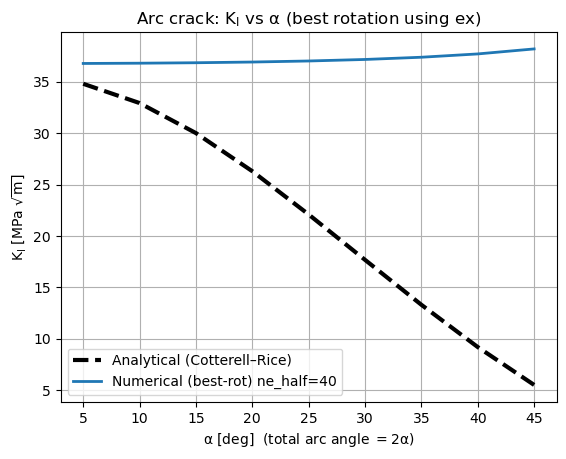

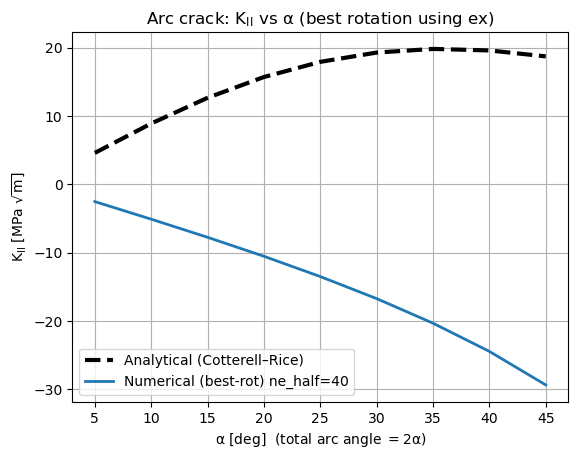

[POLY] nseg=20, ne_half=60


ValueError: Fit window too small after expansion: rr.size=3. Try increasing rho_max (currently 0.6) or increasing n_pts.

In [9]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
# Geometry: total arc angle = 2*alpha  (alpha = half-angle)
#
# Fixes added:
#   (1) Do NOT assume theta=alpha. Compute theta from extra["ex"] if available.
#   (2) Apply BOTH rotation directions (plus/minus) and pick the one that best
#       matches the Cotterell–Rice analytic at each alpha (per-component L2).
#   (3) Print ex/ey/theta_ex diagnostics at alpha=30 deg at the end.
#
# Option (1): ARC geometry, sweep ne_half (small subset)
# Option (2): POLYLINE geometry, fix ne_half, sweep nseg (small subset)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uprocessor.SIF import sif_from_cod_fit

# -------------------------
# Output directory
# -------------------------
out_dir = Path(repo_root) / "output" / "Arc_CR_CotterellRice"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm       # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 100e6
sig_yy = 200e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(5.0, 45.0, 9)   # small subset
alpha = np.deg2rad(alpha_deg)

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",   # keep what works in your pipeline
)

# -------------------------
# Cotterell–Rice analytical SIFs
# CR paper uses total angle = 2*alpha, but formulas contain (alpha/2).
# With alpha here as half-angle, using sin(alpha), cos(3alpha), etc. is consistent.
# Use a_arc (half arc-length) in sqrt(pi*a_arc).
# -------------------------
def cotterell_rice_K(alpha, a_arc, sxx, syy, sxy):
    A0 = 0.5 * (syy + sxx)
    D0 = 0.5 * (syy - sxx)

    s = np.sin(alpha)
    c = np.cos(alpha)

    bracket = A0 - D0 * (s**2) * (c**2)

    KI  = np.sqrt(np.pi * a_arc) * (
        bracket * (c / (1.0 + s**2))
        + D0 * np.cos(3.0 * alpha)
        - sxy * (np.sin(3.0 * alpha) + s**3)
    )

    KII = np.sqrt(np.pi * a_arc) * (
        bracket * (s / (1.0 + s**2))
        + D0 * np.sin(3.0 * alpha)
        + sxy * (np.cos(3.0 * alpha) + c * (s**2))
    )

    return float(KI), float(KII)

# -------------------------
# Geometry builders
# ARC control point is the CIRCLE CENTER (your encoding).
# total angle = 2*alpha, chord endpoints = ±a_chord
# R = a/sin(alpha), center y_c = R cos(alpha)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)   # TRUE circle center

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],   # CONTROL = CENTER
    ], float)

    Econn = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

def polyline_network(alpha, nseg):
    R = a_chord / np.sin(alpha)
    yc = R * np.cos(alpha)

    thL = np.pi/2 + alpha
    thR = np.pi/2 - alpha
    th = np.linspace(thL, thR, nseg + 1)

    x = R * np.cos(th)
    y = -yc + R * np.sin(th)

    V = np.zeros((nseg + 1, 3))
    V[:,0] = np.arange(nseg + 1)
    V[:,1] = x
    V[:,2] = y

    Econn = np.array([[i, i+1] for i in range(nseg)], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=nseg + 1,
        validate=True,
    )

# -------------------------
# SIF rotation helpers (half-angle rotation)
# We compute BOTH directions and choose the better match to analytic.
# -------------------------
def rot_plus(KI, KII, theta):
    # K_rot = K * exp(+i theta/2)
    c = np.cos(0.5*theta); s = np.sin(0.5*theta)
    return KI*c - KII*s, KI*s + KII*c

def rot_minus(KI, KII, theta):
    # K_rot = K * exp(-i theta/2)
    c = np.cos(0.5*theta); s = np.sin(0.5*theta)
    return KI*c + KII*s, -KI*s + KII*c

# -------------------------
# Solver wrapper
# Returns local SIFs, a_arc, ex/ey, theta_ex, and best-rotated "global" SIFs.
# -------------------------
def solve_K(net, ne_half, alpha_for_analytic):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    extra = dict(extra) if isinstance(extra, dict) else {}
    a_arc = float(extra.get("a_edge", np.nan))

    # local tangent/normal as reported by reconstructor
    ex = np.asarray(extra.get("ex", [1.0, 0.0]), float).reshape(2,)
    ey = np.asarray(extra.get("ey", [0.0, 1.0]), float).reshape(2,)
    theta_ex = float(np.arctan2(ex[1], ex[0]))  # angle of reported tangent

    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu)  # plane strain

    KI_loc, KII_loc, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.6,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )
    KI_loc = float(KI_loc); KII_loc = float(KII_loc)

    # analytic (uses same a_arc for consistency)
    KI_a, KII_a = cotterell_rice_K(alpha_for_analytic, a_arc, sig_xx, sig_yy, sig_xy)

    # candidate rotations using theta_ex
    KI_p, KII_p = rot_plus(KI_loc, KII_loc, theta_ex)
    KI_m, KII_m = rot_minus(KI_loc, KII_loc, theta_ex)

    # pick which rotation matches analytic better (component-wise relative L2)
    err_p = (KI_p - KI_a)**2 + (KII_p - KII_a)**2
    err_m = (KI_m - KI_a)**2 + (KII_m - KII_a)**2

    if err_p <= err_m:
        KI_best, KII_best = float(KI_p), float(KII_p)
        rot_choice = "+theta/2"
    else:
        KI_best, KII_best = float(KI_m), float(KII_m)
        rot_choice = "-theta/2"

    return dict(
        KI_loc=KI_loc, KII_loc=KII_loc,
        KI_best=KI_best, KII_best=KII_best,
        a_arc=a_arc,
        ex=ex, ey=ey,
        theta_ex=theta_ex,
        rot_choice=rot_choice,
        KI_ana=KI_a, KII_ana=KII_a
    )

# ============================================================
# OPTION (1): ARC geometry, sweep ne_half (small subset)
# ============================================================
ne_list = [40]  # small subset
scale = 1e-6

# analytic curves (computed with a_arc = R*alpha)
KI_ana = []
KII_ana = []
for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al
    KIa, KIIa = cotterell_rice_K(al, a_arc, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)
KI_ana = np.array(KI_ana, float)
KII_ana = np.array(KII_ana, float)

KI_ana_p = KI_ana * scale
KII_ana_p = KII_ana * scale

KI_arc_best = {ne: np.zeros_like(alpha, float) for ne in ne_list}
KII_arc_best = {ne: np.zeros_like(alpha, float) for ne in ne_list}

for ne in ne_list:
    print(f"[ARC] ne_half = {ne}")
    for i, al in enumerate(alpha):
        net = arc_network(al)
        out = solve_K(net, ne_half=ne, alpha_for_analytic=al)
        KI_arc_best[ne][i]  = out["KI_best"] * scale
        KII_arc_best[ne][i] = out["KII_best"] * scale

# plots
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for ne in ne_list:
    ax1.plot(alpha_deg, KI_arc_best[ne], lw=2, label=f"Numerical (best-rot) ne_half={ne}")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Arc crack: $K_I$ vs $\\alpha$ (best rotation using ex)")
ax1.grid(True); ax1.legend()
fig1.savefig(out_dir/"OPT1_arc_KI_vs_alpha_bestrot.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana_p, "k--", lw=3, label="Analytical (Cotterell–Rice)")
for ne in ne_list:
    ax2.plot(alpha_deg, KII_arc_best[ne], lw=2, label=f"Numerical (best-rot) ne_half={ne}")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Arc crack: $K_{II}$ vs $\\alpha$ (best rotation using ex)")
ax2.grid(True); ax2.legend()
fig2.savefig(out_dir/"OPT1_arc_KII_vs_alpha_bestrot.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# OPTION (2): POLYLINE geometry, fix ne_half, sweep nseg (small subset)
# ============================================================
ne_fixed = 60
nseg_list = [20]  # small subset

KI_poly_best = {nseg: np.zeros_like(alpha, float) for nseg in nseg_list}
KII_poly_best = {nseg: np.zeros_like(alpha, float) for nseg in nseg_list}

for nseg in nseg_list:
    print(f"[POLY] nseg={nseg}, ne_half={ne_fixed}")
    for i, al in enumerate(alpha):
        net = polyline_network(al, nseg=nseg)
        out = solve_K(net, ne_half=ne_fixed, alpha_for_analytic=al)
        KI_poly_best[nseg][i]  = out["KI_best"] * scale
        KII_poly_best[nseg][i] = out["KII_best"] * scale

# ============================================================
# Diagnostics at alpha = 30 deg (END OF CELL)
# ============================================================
alpha_dbg_deg = 30.0
alpha_dbg = np.deg2rad(alpha_dbg_deg)
net_dbg = arc_network(alpha_dbg)
out_dbg = solve_K(net_dbg, ne_half=ne_list[0], alpha_for_analytic=alpha_dbg)

print("\n================ DEBUG at alpha = 30 deg ================")
print(f"alpha_dbg (deg)     = {alpha_dbg_deg}")
print(f"a_chord             = {a_chord}")
print(f"a_arc (solver a_edge)= {out_dbg['a_arc']}")
print(f"R (from chord)      = {a_chord/np.sin(alpha_dbg)}")

print("\nReported local frame:")
print(" ex =", out_dbg["ex"], " ey =", out_dbg["ey"])
print(" theta_ex (deg) =", np.rad2deg(out_dbg["theta_ex"]))
print(" rotation choice =", out_dbg["rot_choice"])

print("\nAnalytical [MPa*sqrt(m)] (uses same a_arc)")
print(" KI  =", out_dbg["KI_ana"] * scale)
print(" KII =", out_dbg["KII_ana"] * scale)

print("\nNumerical LOCAL [MPa*sqrt(m)]")
print(" KI_loc  =", out_dbg["KI_loc"] * scale)
print(" KII_loc =", out_dbg["KII_loc"] * scale)

print("\nNumerical BEST-ROT [MPa*sqrt(m)]")
print(" KI_best  =", out_dbg["KI_best"] * scale)
print(" KII_best =", out_dbg["KII_best"] * scale)

print("\nRatios (BEST/Analytical):")
print(" KI_best / KI_ana   =", out_dbg["KI_best"] / out_dbg["KI_ana"])
print(" KII_best / KII_ana =", out_dbg["KII_best"] / out_dbg["KII_ana"])
print("========================================================")


Using repo_root = C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


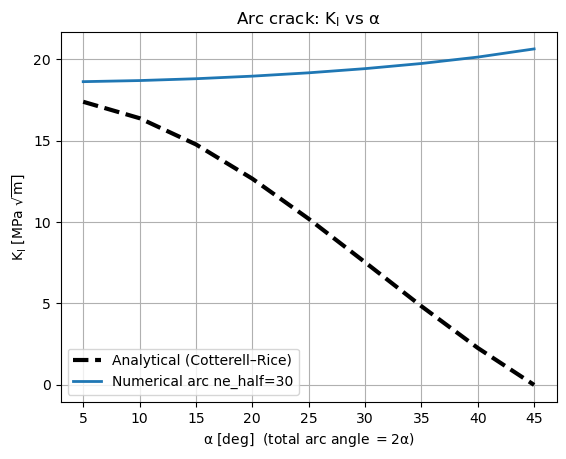

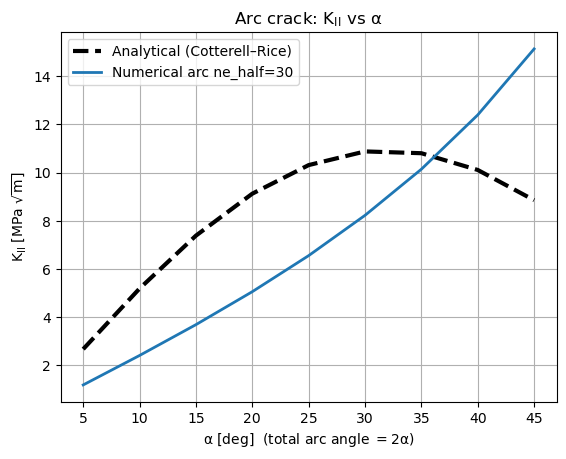


================ DEBUG at alpha = 30 deg ================
a_chord        = 0.01
a_arc (solver) = 0.010471975511965976
a_arc (true)   = 0.010471975511965978
R              = 0.020000000000000004

Analytical [MPa*sqrt(m)]
 KI  = 7.696886009946324
 KII = 11.131371211770611

Numerical [MPa*sqrt(m)]
 KI  = 19.416650766262247
 KII = -8.22740064344893

Ratios:
 KI_num / KI_ana  = 2.5226631576940366
 KII_num / KII_ana = -0.7391183428281554


In [14]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
#
# Geometry:
#   - total arc angle = 2*alpha
#   - alpha here is the HALF-angle
#   - arc is defined by endpoints ±a_chord and the TRUE circle center
#
# IMPORTANT:
#   K_I, K_II returned by sif_from_cod_fit are already in the
#   PHYSICAL crack-tip frame → NO local/global rotation applied.
#
# Diagnostics printed at alpha = 30 deg
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Ensure repo root on sys.path
# -------------------------
cwd = Path(os.getcwd()).resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "fracture_utils").is_dir():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo_root =", repo_root)

from preamble import *
enable_autoreload()

from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uprocessor.SIF import sif_from_cod_fit

# -------------------------
# Output directory
# -------------------------
out_dir = Path(repo_root) / "output" / "Arc_CR_CotterellRice_fixed"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm     # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(5.0, 45.0, 9)
alpha = np.deg2rad(alpha_deg)

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

# -------------------------
# Cotterell–Rice analytical SIFs
# alpha = half-angle, formulas already contain alpha/2
# a_arc = half ARC length = R * alpha
# -------------------------
def cotterell_rice_K(alpha, a_arc, sxx, syy, sxy):
    A0 = 0.5 * (syy + sxx)
    D0 = 0.5 * (syy - sxx)

    s = np.sin(alpha/2)
    c = np.cos(alpha/2)

    bracket = A0 - D0 * (s**2) * (c**2)

    KI  = np.sqrt(np.pi * a_arc) * (
        bracket * (c / (1.0 + s**2))
        + D0 * np.cos(3.0 * alpha)
        - sxy * (np.sin(3.0 * alpha) + s**3)
    )

    KII = np.sqrt(np.pi * a_arc) * (
        bracket * (s / (1.0 + s**2))
        + D0 * np.sin(3.0 * alpha)
        + sxy * (np.cos(3.0 * alpha) + c * s**2)
    )

    return KI, KII

# -------------------------
# Arc geometry (TRUE circle center)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)     # TRUE center

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],     # CONTROL = CENTER
    ], float)

    E = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=E,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

# -------------------------
# Solver wrapper
# -------------------------
def solve_K(net, ne_half):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    a_arc = float(extra["a_edge"])  # HALF ARC LENGTH

    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu)

    KI, KII, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.6,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    return float(KI), float(KII), a_arc

# ============================================================
# Run: ARC geometry, ne_half = 30
# ============================================================
ne_half = 30
scale = 1e-6

KI_num = []
KII_num = []
KI_ana = []
KII_ana = []

for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al

    KIa, KIIa = cotterell_rice_K(al, a_chord, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

    net = arc_network(al)
    KIn, KIIn, _ = solve_K(net, ne_half)
    KI_num.append(KIn)
    KII_num.append(KIIn)

KI_ana = np.array(KI_ana)
KII_ana = np.array(KII_ana)
KI_num = np.array(KI_num)
KII_num = np.array(KII_num)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax1.plot(alpha_deg, KI_num*scale, lw=2, label=f"Numerical arc ne_half={ne_half}")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Arc crack: $K_I$ vs $\\alpha$")
ax1.grid(True); ax1.legend()
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax2.plot(alpha_deg,- KII_num*scale, lw=2, label=f"Numerical arc ne_half={ne_half}")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Arc crack: $K_{II}$ vs $\\alpha$")
ax2.grid(True); ax2.legend()
plt.show()

# ============================================================
# Diagnostics at alpha = 30 deg
# ============================================================
alpha_dbg = np.deg2rad(30.0)
R_dbg = a_chord / np.sin(alpha_dbg)
a_arc_dbg = R_dbg * alpha_dbg

net_dbg = arc_network(alpha_dbg)
KI_n, KII_n, a_arc_solver = solve_K(net_dbg, ne_half)
KI_a, KII_a = cotterell_rice_K(alpha_dbg, a_arc_dbg, sig_xx, sig_yy, sig_xy)

print("\n================ DEBUG at alpha = 30 deg ================")
print(f"a_chord        = {a_chord}")
print(f"a_arc (solver) = {a_arc_solver}")
print(f"a_arc (true)   = {a_arc_dbg}")
print(f"R              = {R_dbg}")

print("\nAnalytical [MPa*sqrt(m)]")
print(" KI  =", KI_a * scale)
print(" KII =", KII_a * scale)

print("\nNumerical [MPa*sqrt(m)]")
print(" KI  =", KI_n * scale)
print(" KII =", KII_n * scale)

print("\nRatios:")
print(" KI_num / KI_ana  =", KI_n / KI_a)
print(" KII_num / KII_ana =", KII_n / KII_a)
print("========================================================")
